In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from ultralytics import YOLO

In [ ]:
from ultralytics import YOLO

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
results = model.predict('/content/drive/MyDrive/IMG20241122164810.jpg')

result = results[0]
print(result)
result.show()
result.save(filename='result.jpg')

Output hidden; open in https://colab.research.google.com to view.


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 175.2ms
Speed: 4.5ms preprocess, 175.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)


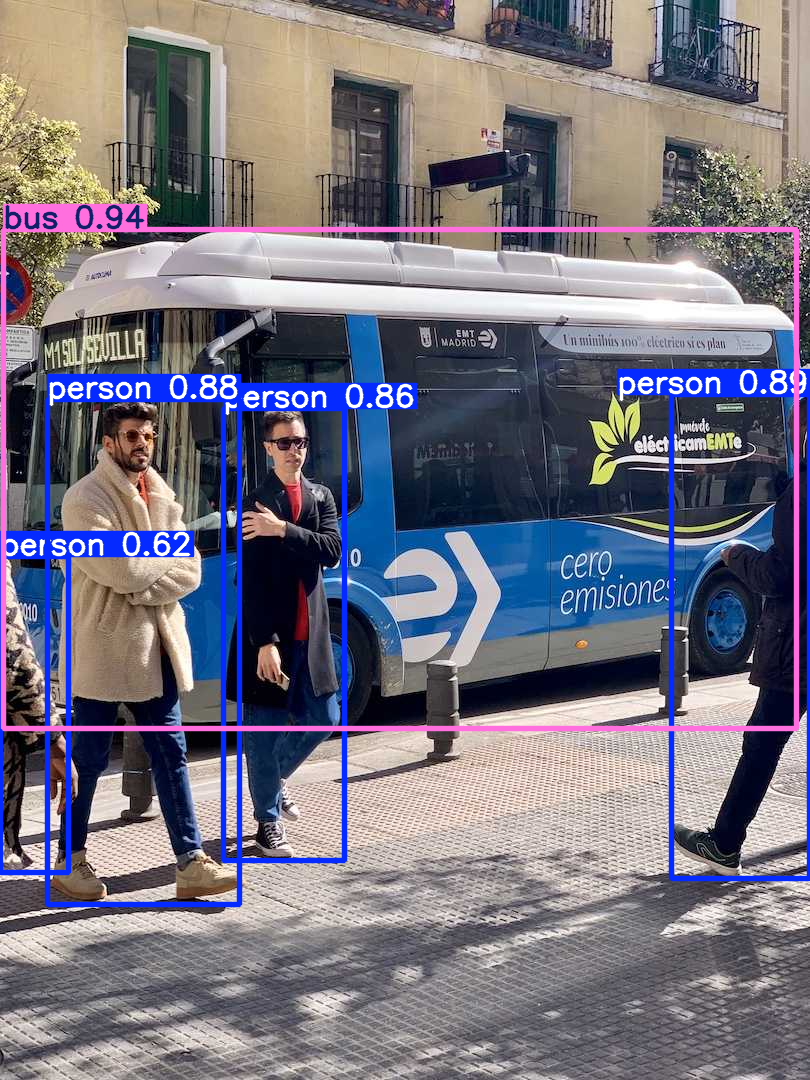

In [ ]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')
results = model.predict('https://ultralytics.com/images/bus.jpg')

for result in results:
    result.show()
    result.save(filename='result1.jpg')

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="B83fd3GzmveBBhIMVjfr")
project = rf.workspace("ashurdlcv").project("face_detection-io4hv")
version = project.version(3)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
dataset.location

'/content/Face_detection-3'

In [ ]:
!yolo task=detect mode=train data={dataset.location}/data.yaml model="yolo11n.pt" epochs=60 imgsz=640

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Face_detection-3/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=Tru

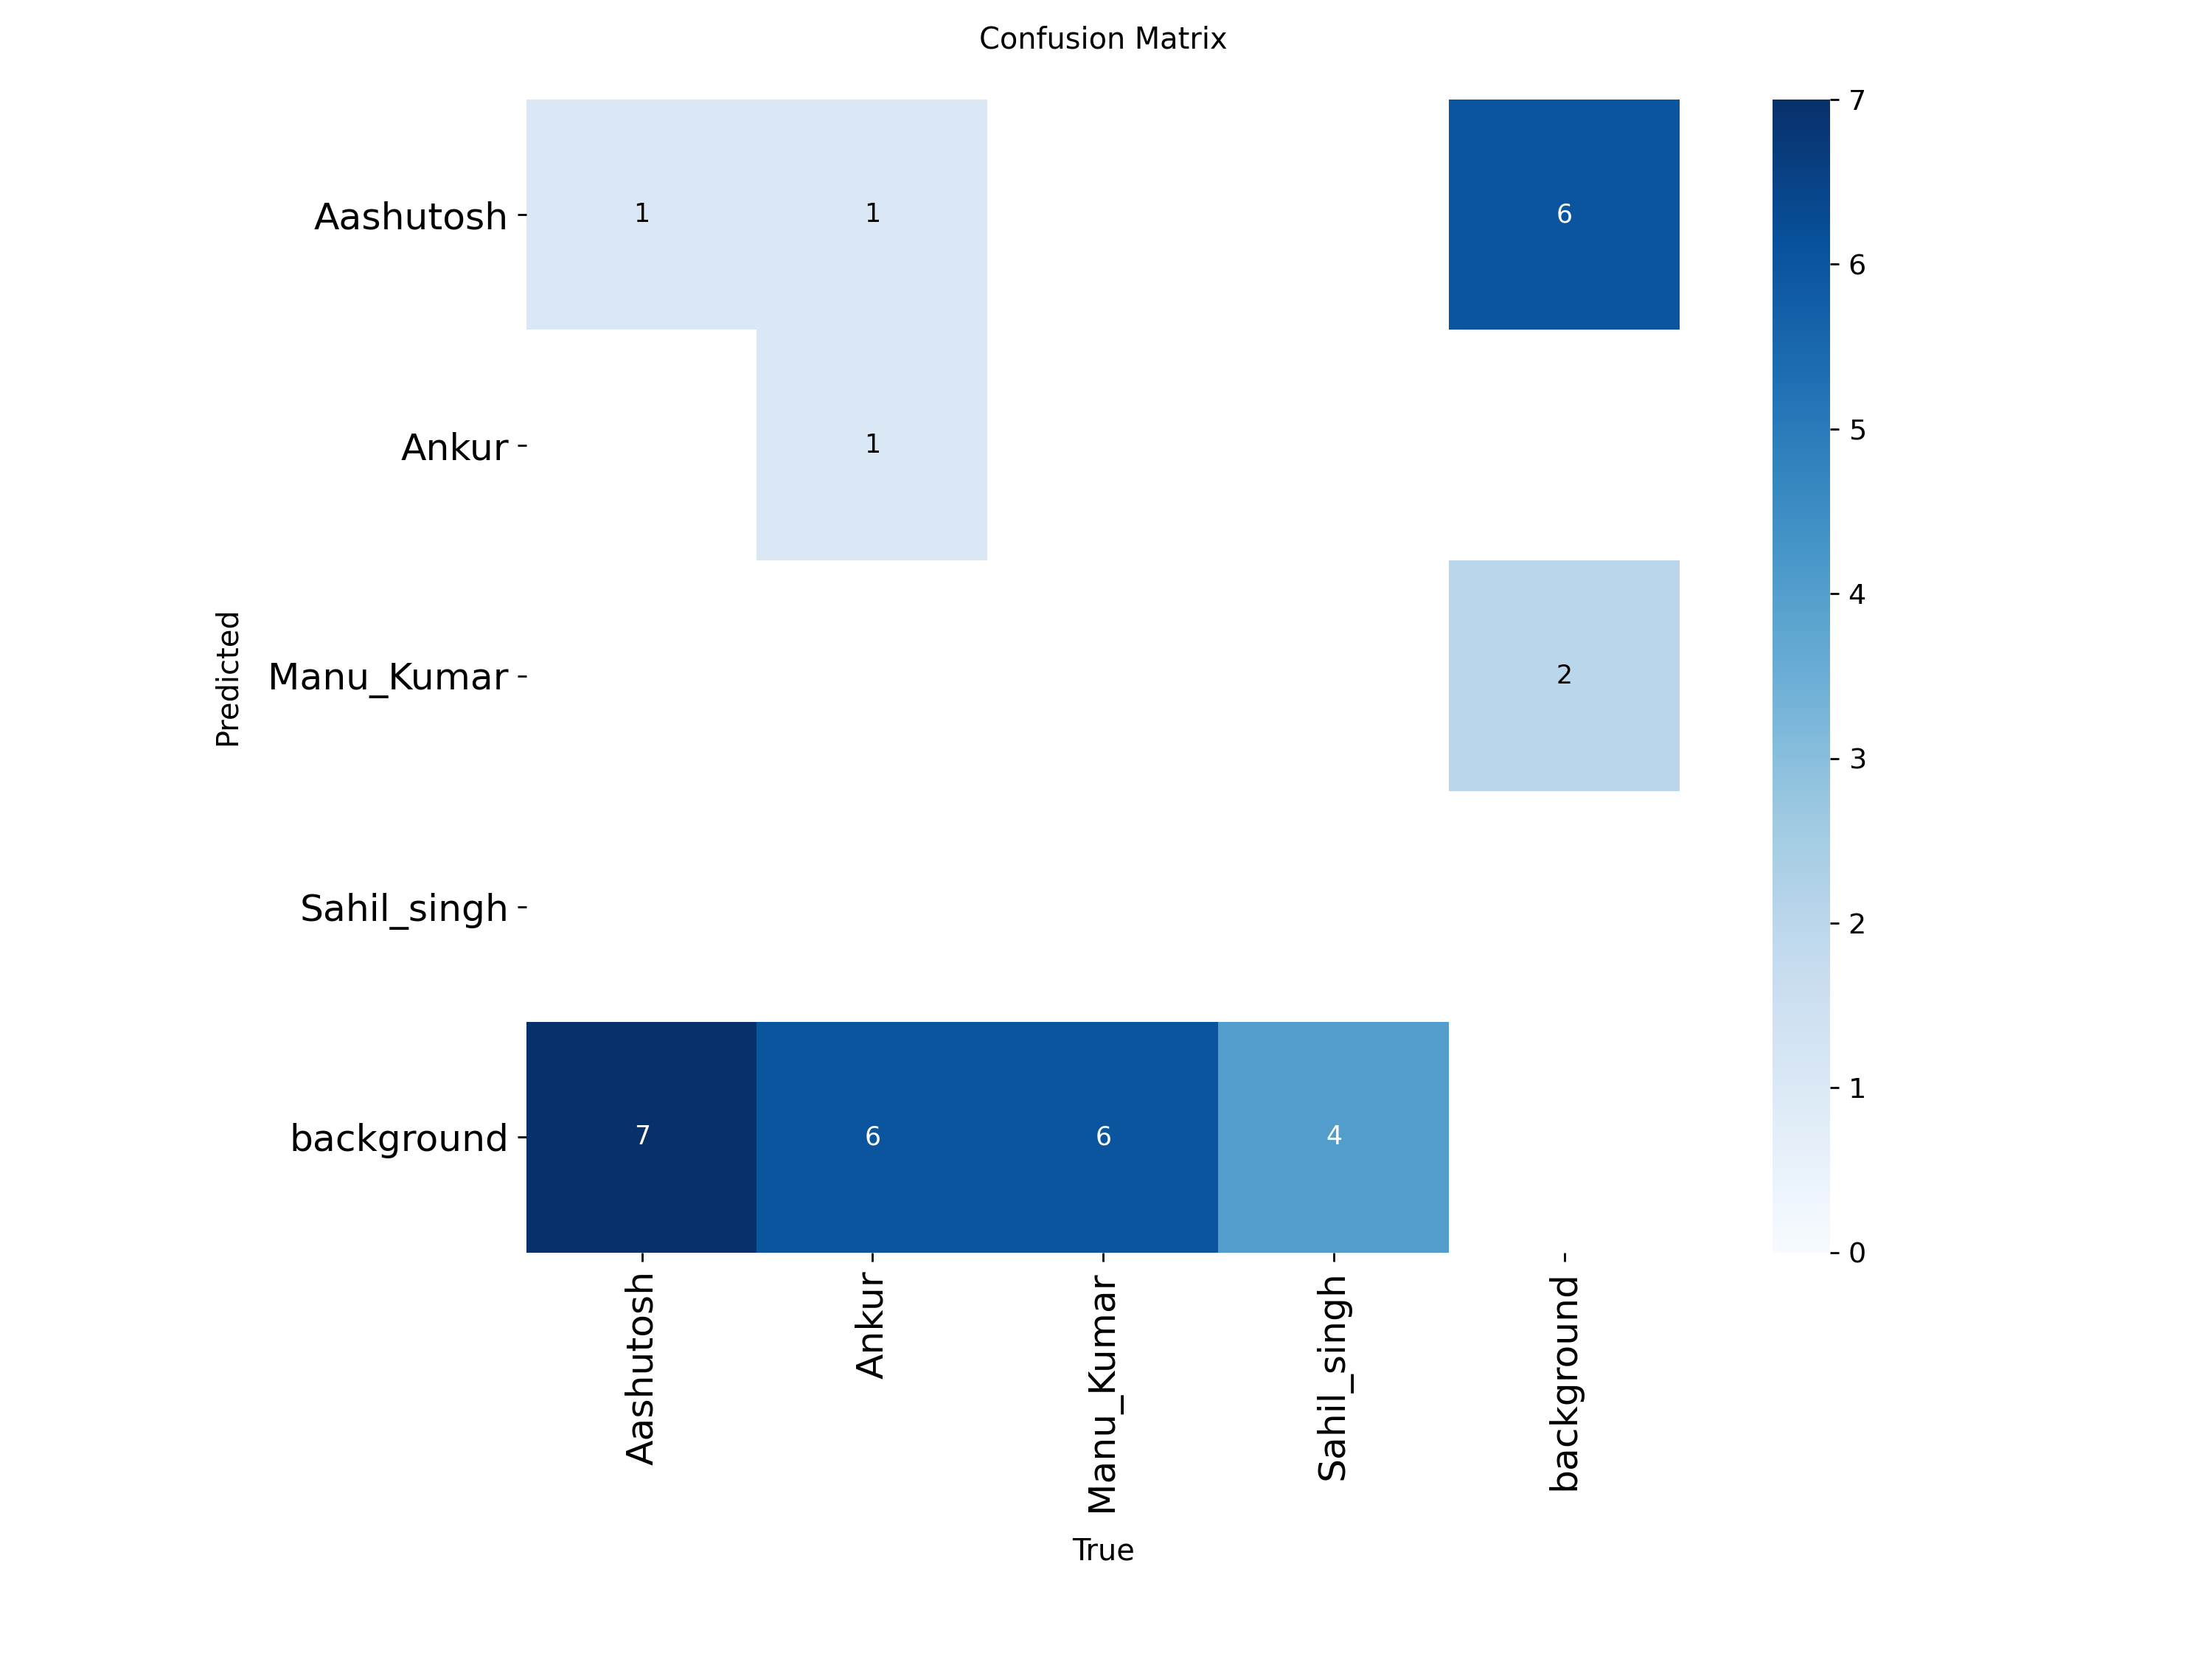

In [ ]:
from IPython.display import Image
Image("/content/runs/detect/train/confusion_matrix.png", width=600)

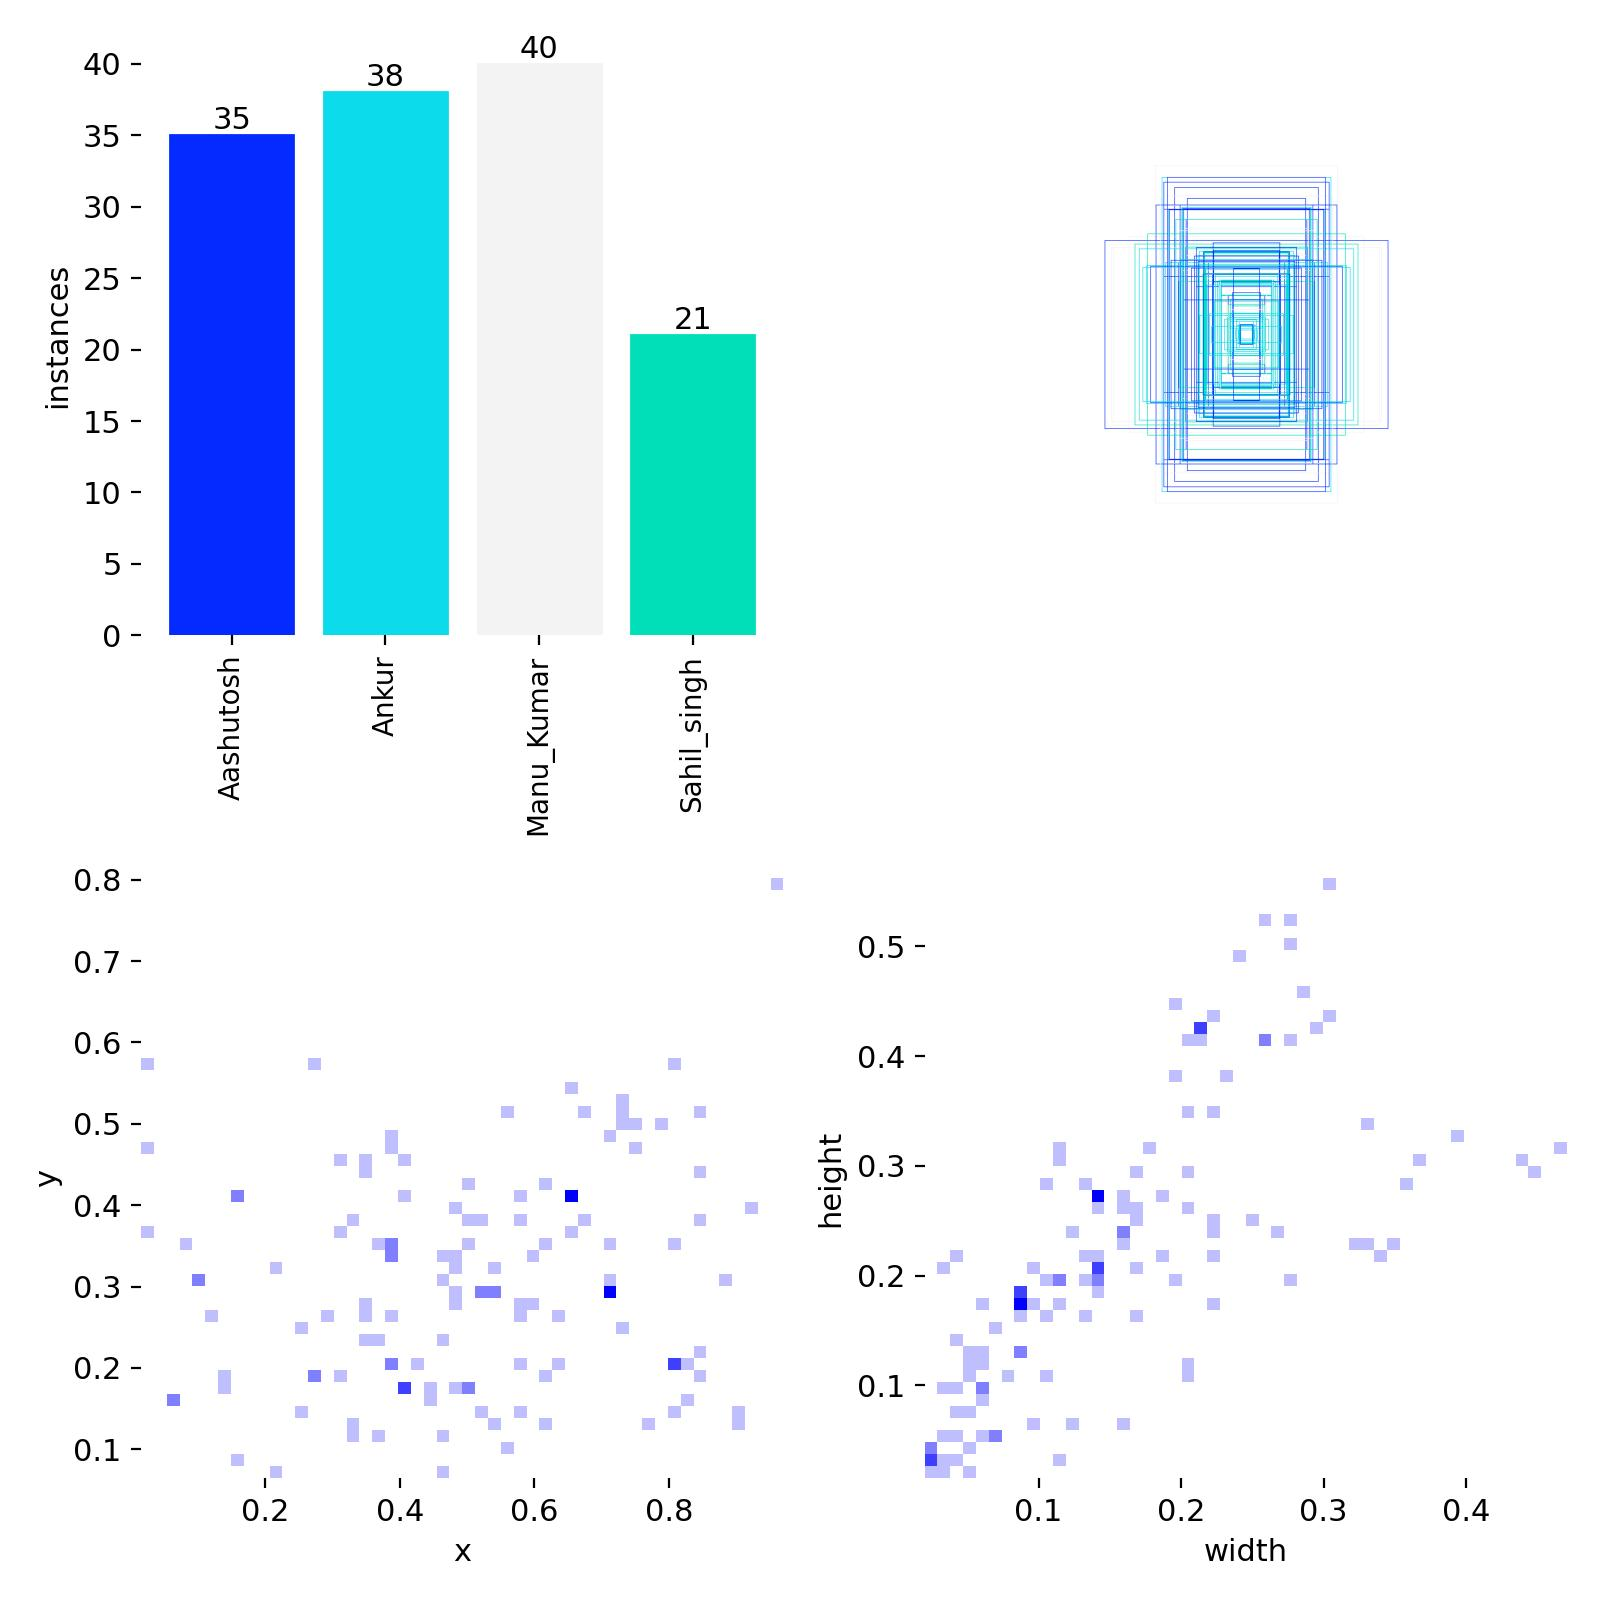

In [ ]:
Image("/content/runs/detect/train/labels.jpg", width=600)

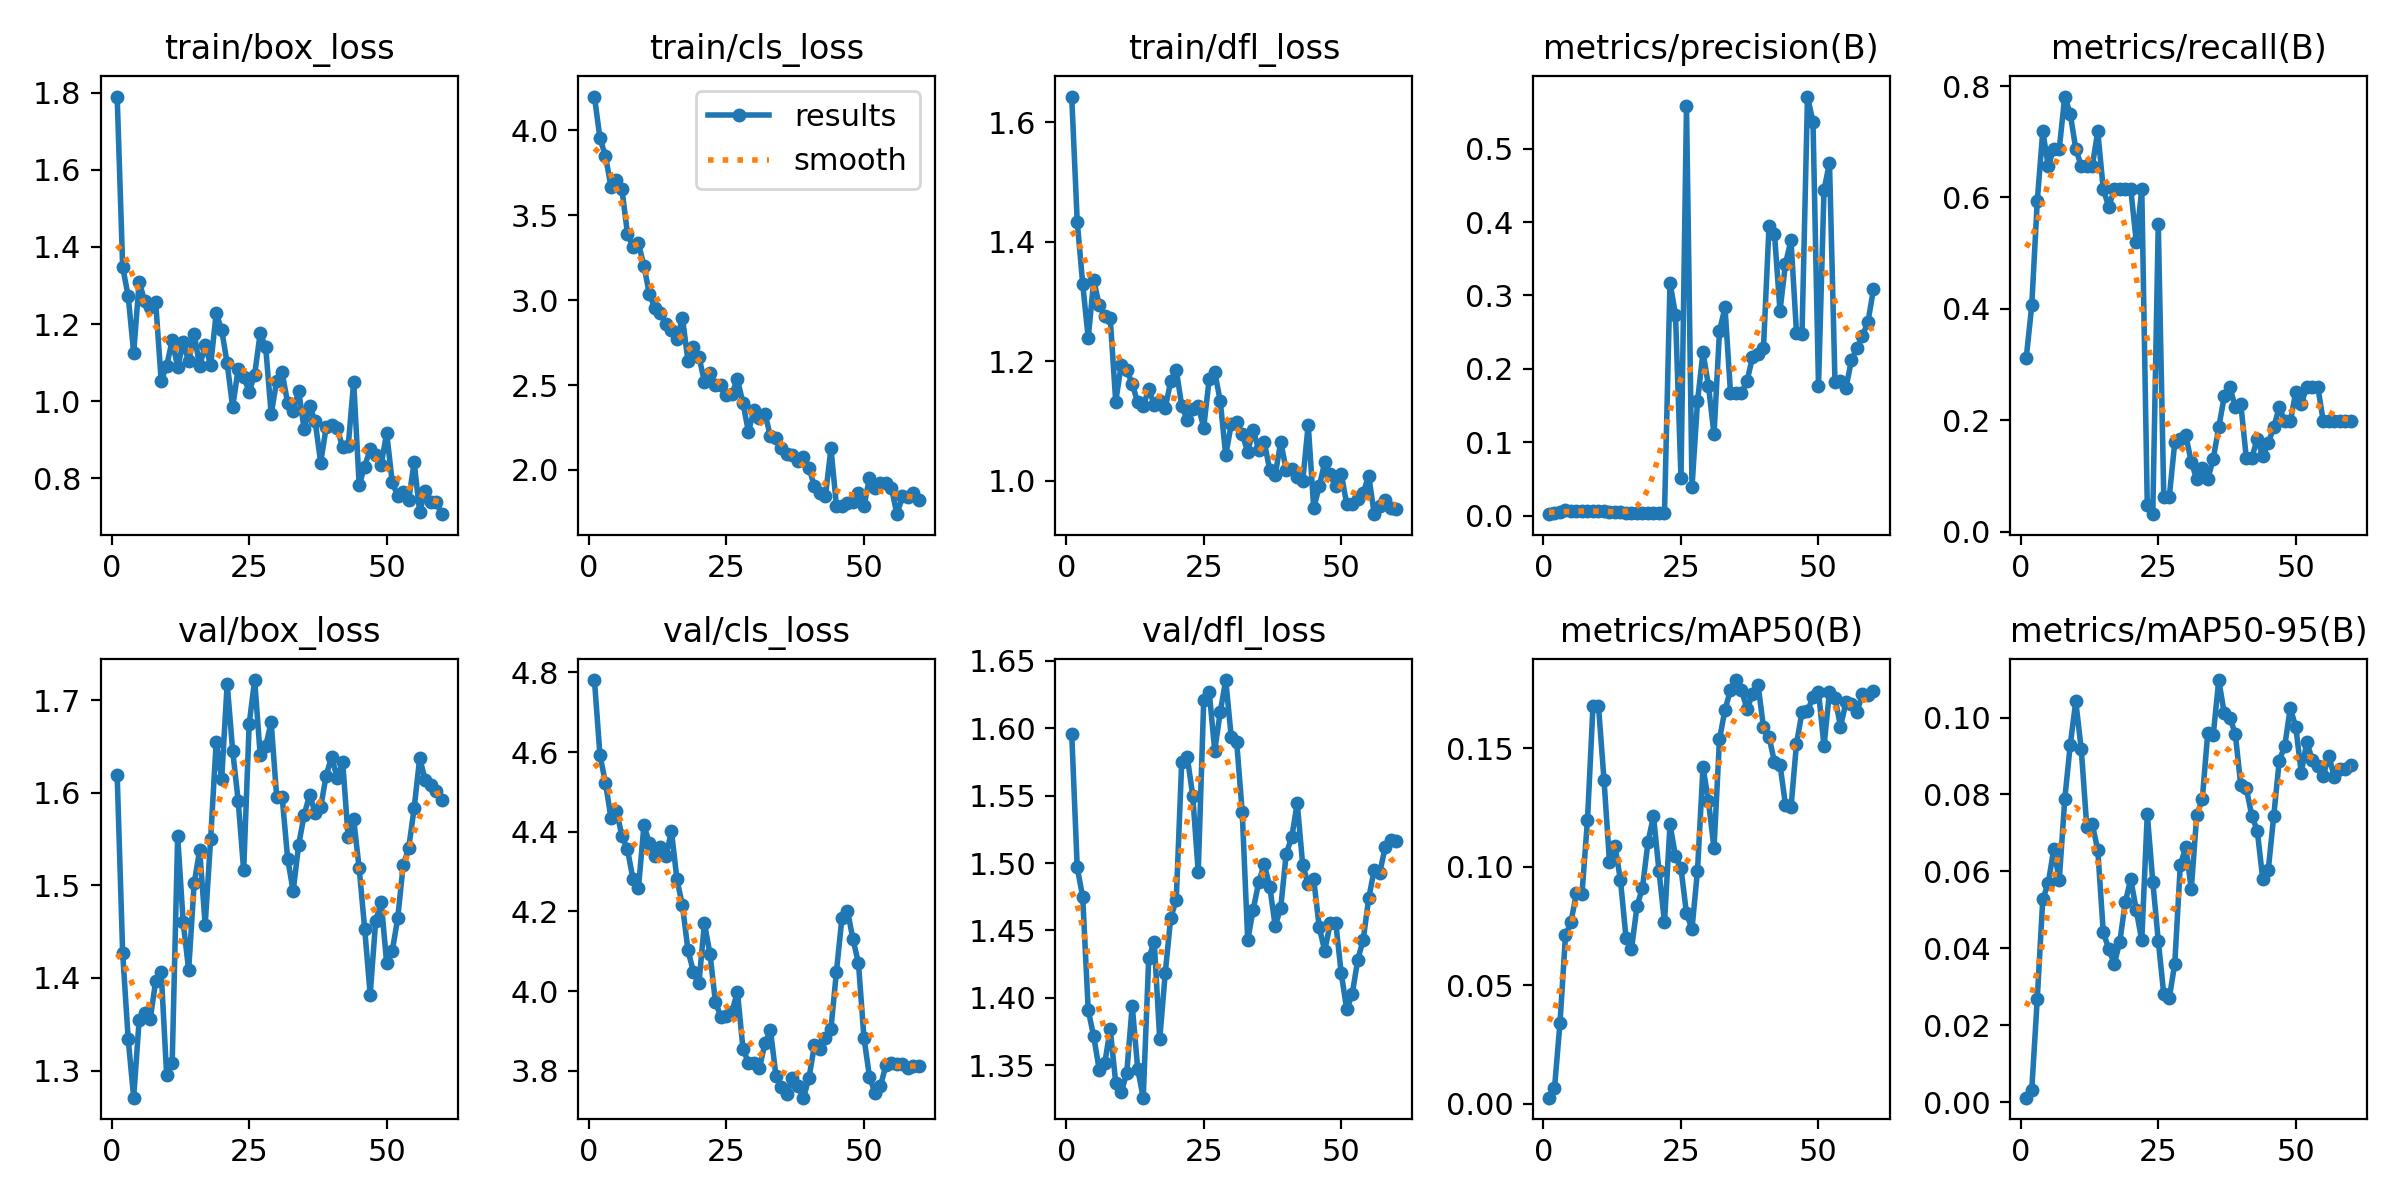

In [ ]:
Image("/content/runs/detect/train/results.png", width=600)

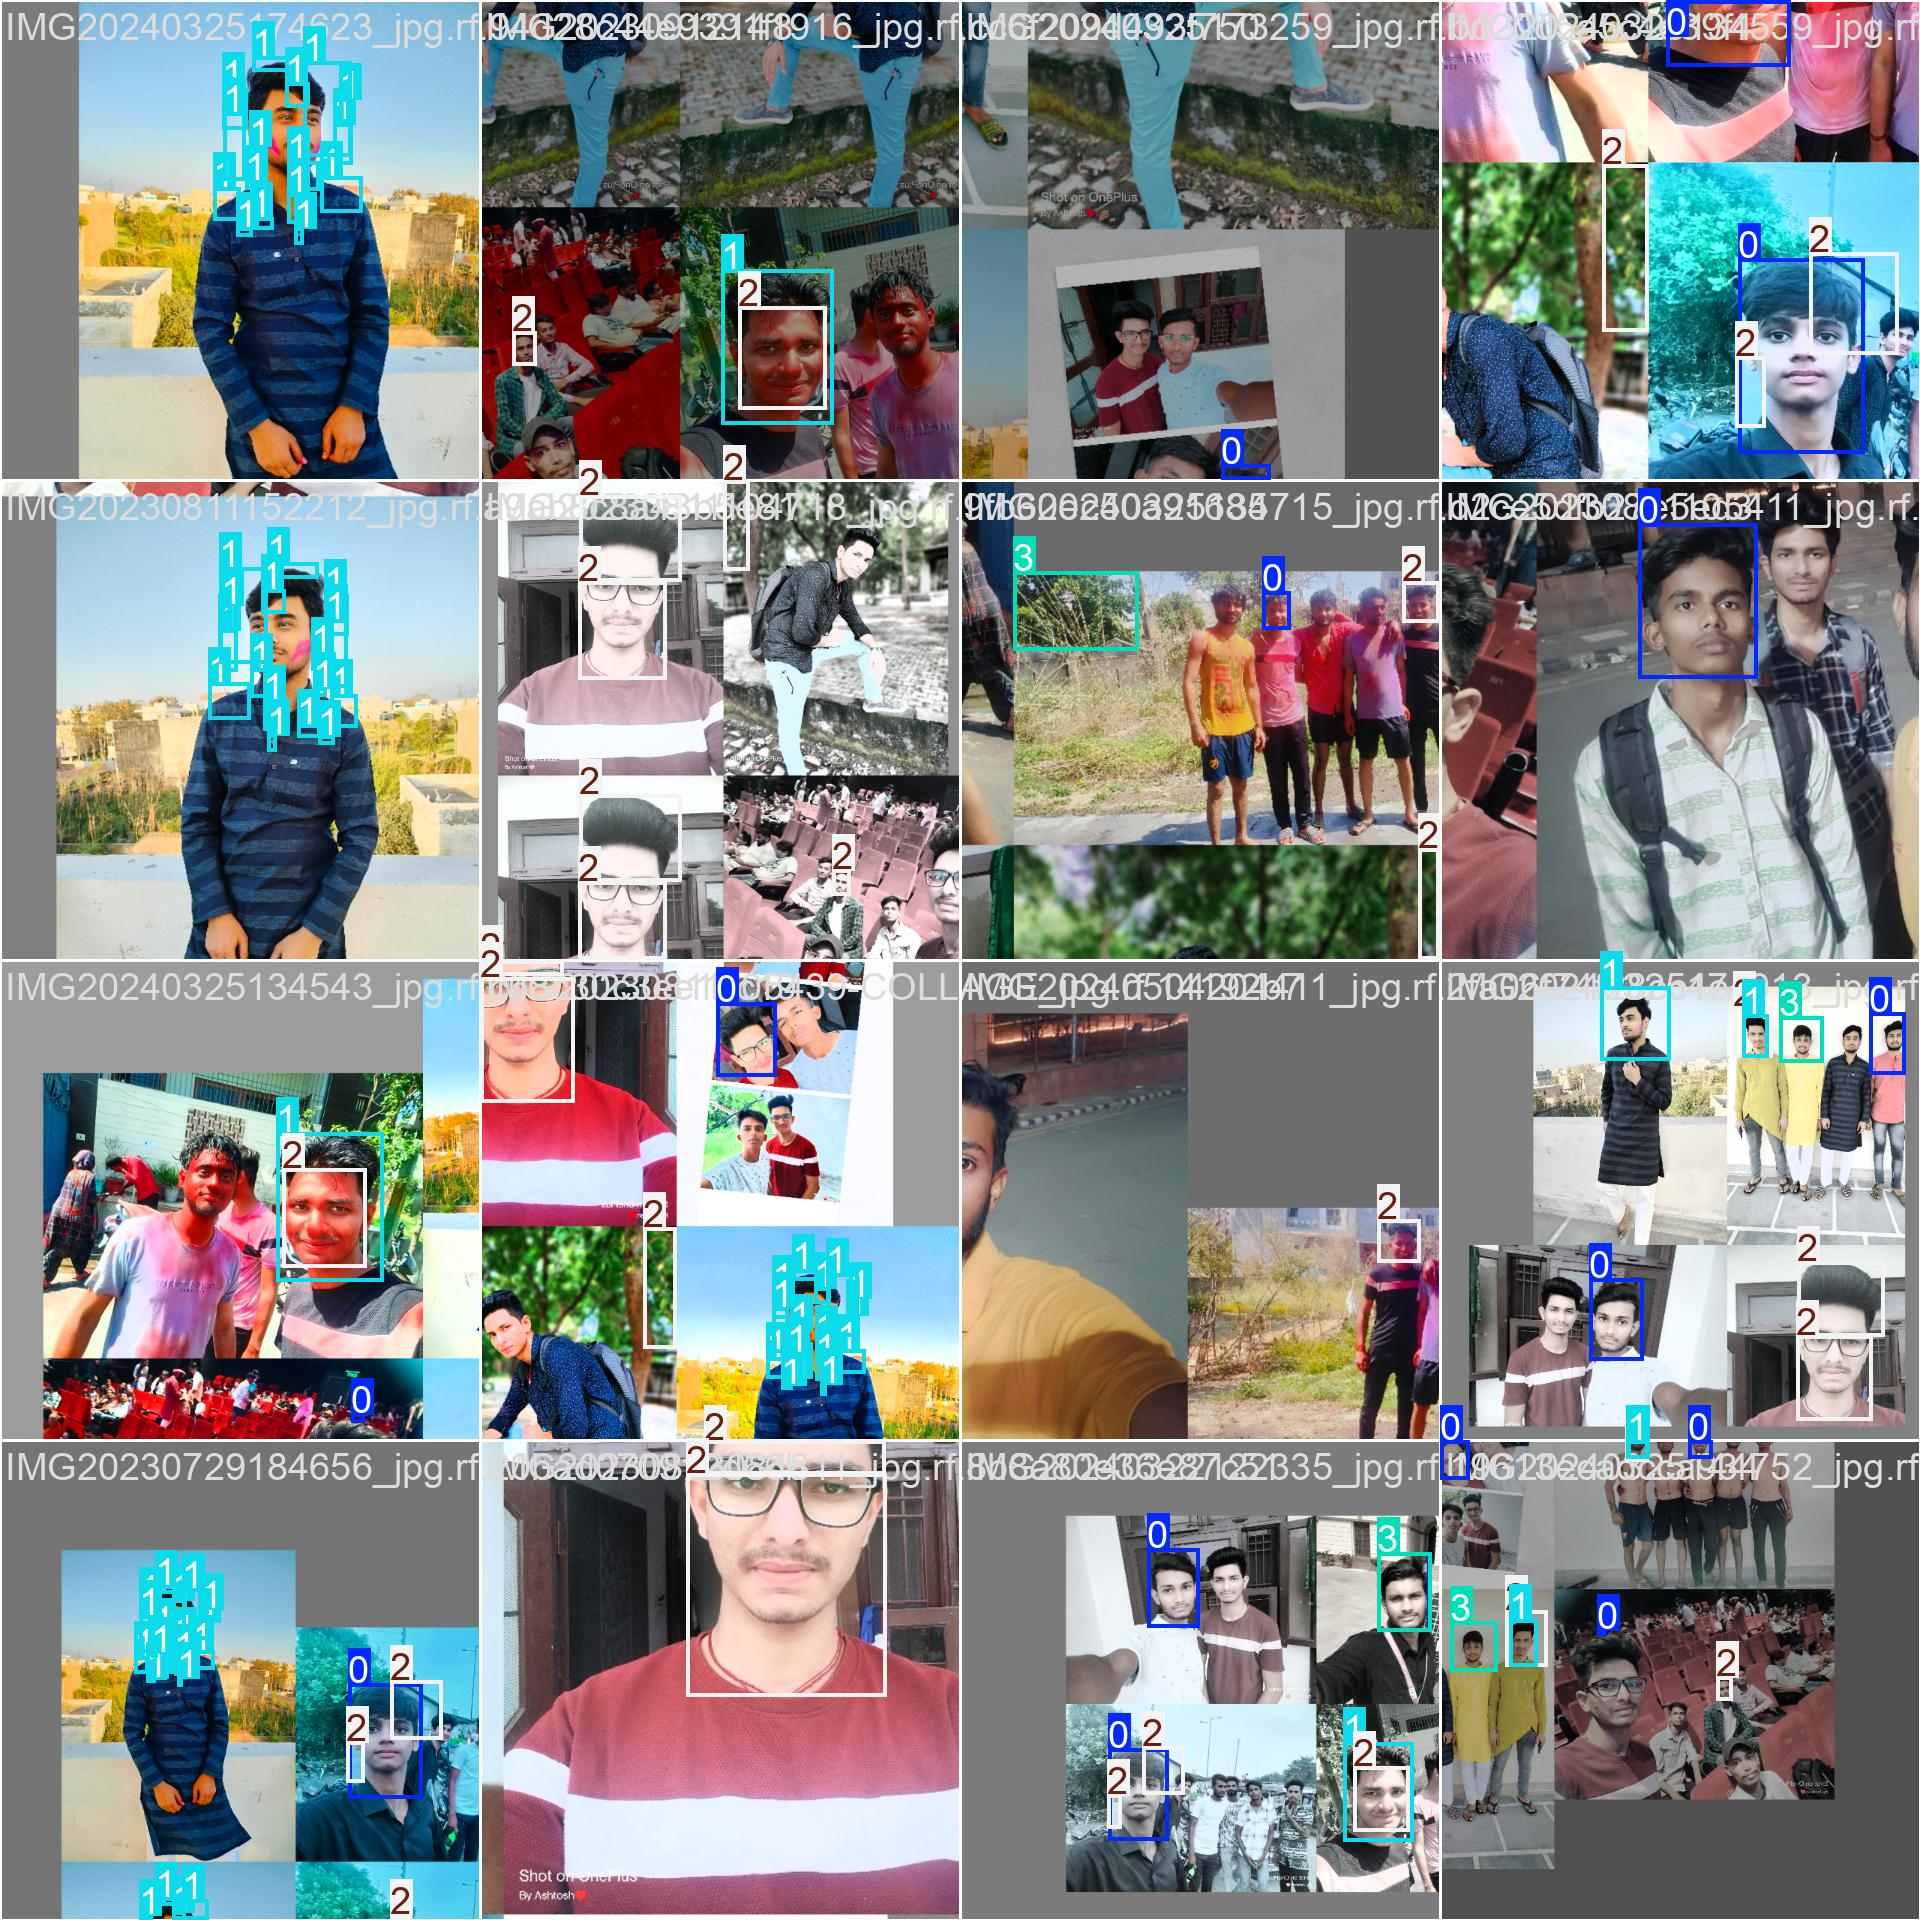

In [ ]:
Image("/content/runs/detect/train/train_batch0.jpg", width=600)

In [ ]:
Image("/content/runs/detect/predict/result.jpg", width=600)

FileNotFoundError: No such file or directory: '/content/runs/detect/predict/result.jpg'

FileNotFoundError: No such file or directory: '/content/runs/detect/predict/result.jpg'

<IPython.core.display.Image object>

In [ ]:
from ultralytics import YOLO

# Load the trained model
# The 'best.pt' file is saved in the runs/detect/train directory by default
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Path to your new image or image folder
# Replace 'new_image.jpg' with the actual path to your image
# For demonstration, I'll use the 'bus.jpg' which was downloaded earlier
new_image_path = '/content/IMG_20230701_115117.jpg'

# Make predictions on the new image
results = model.predict(new_image_path)

# Process and display results
for r in results:
    print(r.boxes)
    r.show() # Display the image with predictions
    r.save(filename='predicted_new_image.jpg') # Save the predicted image

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train/weights/best.pt')

new_image_path = '/content/IMG20230823084843.jpg'

results = model.predict(new_image_path)

for r in results:
    print(r.boxes)
    r.show()
    r.save(filename='predicted_new_image.jpg')

Output hidden; open in https://colab.research.google.com to view.

Capturing image from webcam...
Image captured. Running prediction...

image 1/1 /content/webcam_capture.jpg: 480x640 (no detections), 146.5ms
Speed: 2.4ms preprocess, 146.5ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([])
conf: tensor([])
data: tensor([], size=(0, 6))
id: None
is_track: False
orig_shape: (480, 640)
shape: torch.Size([0, 6])
xywh: tensor([], size=(0, 4))
xywhn: tensor([], size=(0, 4))
xyxy: tensor([], size=(0, 4))
xyxyn: tensor([], size=(0, 4))
Prediction saved to predicted_webcam_result.jpg


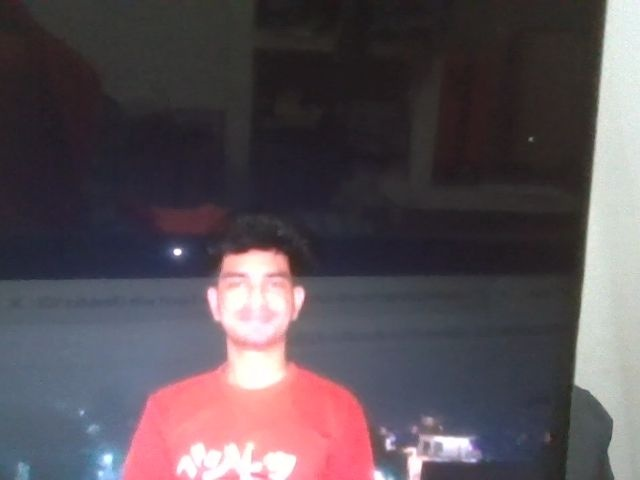

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import display, Javascript, Image

# Step 3: JavaScript to capture webcam frame
def take_photo(filename='photo.jpg', quality=0.8):
    # Construct the JavaScript code string directly
    js_code = '''
        async function takePhotoFunction(quality) {
          const div = document.createElement('div');
          const video = document.createElement('video');
          div.appendChild(video);
          document.body.appendChild(div);
          video.style.display = 'block';

          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          video.srcObject = stream;
          await video.play();

          // Wait for user to click
          const button = document.createElement('button');
          button.textContent = 'Capture';
          div.appendChild(button);

          await new Promise((resolve) => button.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getTracks().forEach(track => track.stop());
          div.remove();

          return canvas.toDataURL('image/jpeg', quality);
        }
        takePhotoFunction(%f); // Call the function defined above
    ''' % quality

    data = eval_js(js_code) # Pass the JavaScript code string to eval_js
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Step 4: Load your trained YOLO model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Step 5: Capture from webcam and run detection
print('Capturing image from webcam...')
image_path = take_photo(filename='webcam_capture.jpg')
print('Image captured. Running prediction...')
results = model.predict(image_path)

# Step 6: Show results
for r in results:
    print(r.boxes)
    # Instead of r.show(), save the image and then display it using IPython.display.Image
    output_filename = 'predicted_webcam_result.jpg'
    r.save(filename=output_filename)
    print(f"Prediction saved to {output_filename}")
    display(Image(output_filename)) # Display the saved image in Colab

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train/weights/best.pt')

new_image_path = '/content/IMG20240325173452.jpg'

results = model.predict(new_image_path)

for r in results:
    print(r.boxes)
    r.show()
    r.save(filename='predicted_new_image.jpg')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train/weights/best.pt')

new_image_path = '/content/IMG20240325173212.jpg'

results = model.predict(new_image_path)

for r in results:
    print(r.boxes)
    r.show()
    r.save(filename='predicted_new_image.jpg')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train/weights/best.pt')

new_image_path = '/content/IMG20240420204905.jpg'

results = model.predict(new_image_path)

for r in results:
    print(r.boxes)
    r.show()
    r.save(filename='predicted_new_image.jpg')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train/weights/best.pt')

new_image_path = '/content/IMG20240506200600.jpg'

results = model.predict(new_image_path)

for r in results:
    print(r.boxes)
    r.show()
    r.save(filename='predicted_new_image.jpg')

Output hidden; open in https://colab.research.google.com to view.